In [ ]:
import os
import gdown
import anndata as ad
import scanpy as sc
# ==== Google Drive のファイル ID ====
# ※ ここに対象 H5AD のファイル ID を書いてください
file_id = "1cProQIHN_auFCowchTcW9-wd1PEPSDjF"

# ==== パス設定 ====
download_dir = "/home/suzuki/Projects/scDiffusion/work/20260215_embryonic/data"
os.makedirs(download_dir, exist_ok=True)

# 元ファイル名（Drive 側の拡張子）
drive_filename = "Embryonic_raw_data.h5ad"

# ダウンロード先パス
local_download_path = os.path.join(download_dir, drive_filename)

# 保存先のファイル名（加工後）
output_path = os.path.join(download_dir, "Embryonic.h5ad")

# ==== Google Drive からダウンロード ====
print(f"Downloading from Google Drive: {file_id} → {local_download_path}")

# URL は gdown 用に組み立て
gdrive_url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(
    url=gdrive_url,
    output=local_download_path,
    quiet=False
)

print("Download finished.")




Downloading...
From (original): https://drive.google.com/uc?id=1cProQIHN_auFCowchTcW9-wd1PEPSDjF
From (redirected): https://drive.google.com/uc?id=1cProQIHN_auFCowchTcW9-wd1PEPSDjF&confirm=t&uuid=8957f69d-3c58-4448-a02a-8316908256aa
To: /home/suzuki/Projects/scDiffusion/work/20260215_embryonic/data/Embryonic_raw_data.h5ad
100%|██████████| 998M/998M [00:12<00:00, 81.2MB/s] 


Download finished.
Reading with anndata…
Saving to /home/suzuki/Projects/scDiffusion/work/20260215_embryonic/data/Embryonic.h5ad
Done.


In [4]:
# ==== AnnData として読み込んでそのまま書き出す ====
print("Reading with anndata…")
adata = ad.read_h5ad(local_download_path)

Reading with anndata…


In [5]:
adata

AnnData object with n_obs × n_vars = 156726 × 32397
    obs: 'Age', 'ClassAnn', 'Souporcell', 'Subclass', 'Superclass', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'suspension_type', 'tissue_type', 'dissection', 'fraction_mitochondrial', 'fraction_unspliced', 'total_genes', 'total_UMIs', 'sample_id', 'CellType', 'cluster_id', 'cell_type_ontology_term_id', 'tissue_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'Chromosome', 'End', 'Gene', 'Start', 'Strand', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'citation', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_UMAP', 'X_tSNE'
    varm: 'HPF', 'HPF_be

In [13]:
columns_rename = list(adata.obs.columns)
columns_rename[1] = "celltype"
adata.obs.columns = columns_rename

columns_rename = list(adata.var.columns)
columns_rename[2] = "gene_name"
adata.var.columns = columns_rename

In [17]:
# Apply filtering
print("Applying filtering...")
sc.pp.filter_cells(adata, min_genes=10)
sc.pp.filter_genes(adata, min_cells=3)
print(f"Data shape after filtering: {adata.shape}")
# Apply normalization and log transformation
print("Applying normalization and log transformation...")
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
print("Normalization and log transformation completed")

# --- HVG selection ---
print("Selecting highly variable genes...")
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=1024,         # HVG 1024 genes (20251218 version)
    # flavor="seurat_v3",     # Optional: specify flavor if needed (e.g., 'seurat_v3')
    subset=True,               # Subset to HVG only
    inplace=True
)
print(f"Number of HVG kept: {adata.n_vars}")

# Apply z-score normalization
print("Applying z-score normalization...")
sc.pp.scale(adata, zero_center=True)
print("Z-score normalization completed")

Applying filtering...
Data shape after filtering: (156726, 29332)
Applying normalization and log transformation...
Normalization and log transformation completed
Selecting highly variable genes...


/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:216: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']


Number of HVG kept: 1024
Applying z-score normalization...
Z-score normalization completed


In [19]:
# Verify the saved data
print("\n=== Verification ===")
print(f"Final data shape: {adata.shape}")
print(f"adata.var columns: {list(adata.var.columns)}")
print(f"'gene_name' column exists in adata.var: {'gene_name' in adata.var.columns}")
print(f"adata.obs columns: {list(adata.obs.columns)}")
print(f"'celltype' column exists in adata.obs: {'celltype' in adata.obs.columns}")
print(f"adata.n_vars (number of genes): {adata.n_vars}")
print(f"adata.n_obs (number of cells): {adata.n_obs}")


=== Verification ===
Final data shape: (156726, 1024)
adata.var columns: ['Chromosome', 'End', 'gene_name', 'Start', 'Strand', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std']
'gene_name' column exists in adata.var: True
adata.obs columns: ['Age', 'celltype', 'Souporcell', 'Subclass', 'Superclass', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'suspension_type', 'tissue_type', 'dissection', 'fraction_mitochondrial', 'fraction_unspliced', 'total_genes', 'total_UMIs', 'sample_id', 'CellType', 'cluster_id', 'cell_type_ontology_term_id', 'tissue_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes']
'ce

In [20]:
print("Saving to", output_path)
adata.write_h5ad(output_path, compression="gzip")

print("Done.")

Saving to /home/suzuki/Projects/scDiffusion/work/20260215_embryonic/data/Embryonic.h5ad
Done.


/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


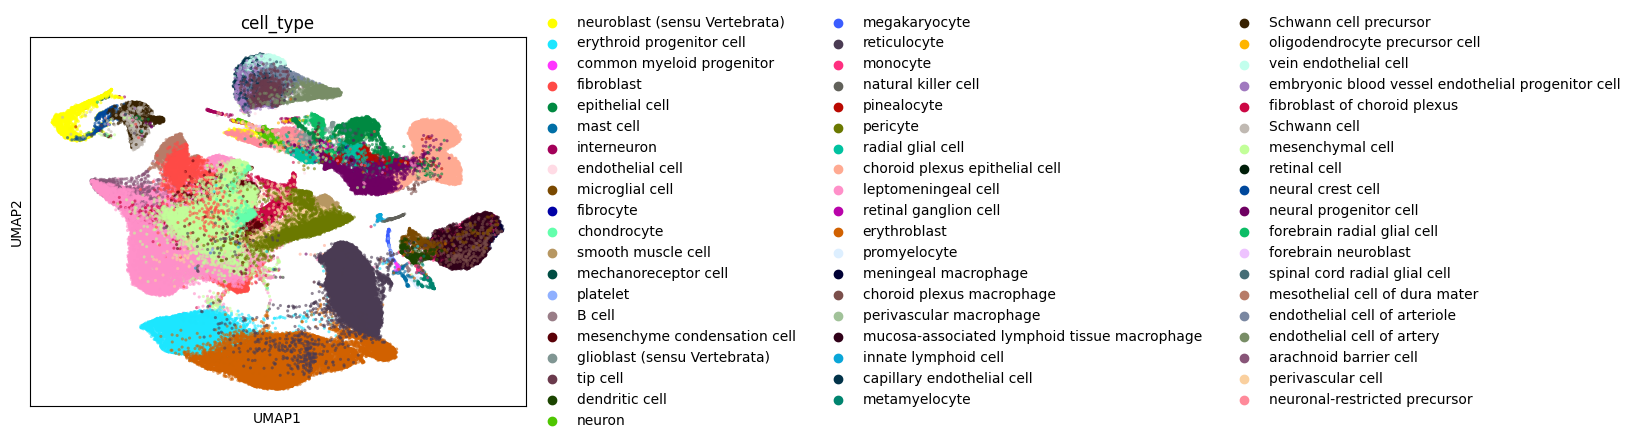

In [21]:
import matplotlib.pyplot as plt
# ノートブックのパラメータに準拠
sc.tl.pca(adata, svd_solver='arpack', n_comps=50)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=40)
sc.tl.umap(adata)
sc.pl.umap(adata, color="cell_type", 
            size=20, alpha=0.6)